In [2]:
import open3d as o3d
import numpy as np
from importlib import reload
import cv2 as cv
import matplotlib.pyplot as plt
import os
# import simple
# reload(simple)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [8]:
import cv2
data_path = "E:\\multi_source_info\\lidar\\results_0309_0p001\\ore_patches"

thickness = cv2.imread(os.path.join(data_path, "ore_0_thickness.tif"), cv2.IMREAD_UNCHANGED)  # float32
mask = cv2.imread(os.path.join(data_path, "ore_0_mask.png"), cv2.IMREAD_GRAYSCALE)            # uint8
xrt_low = cv2.imread(os.path.join(data_path, "ore_0_xrt_low.png"), cv2.IMREAD_GRAYSCALE)     # uint8


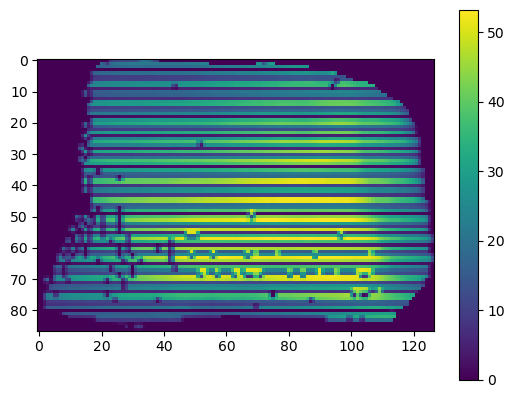

In [9]:
plt.imshow(thickness)
plt.colorbar()

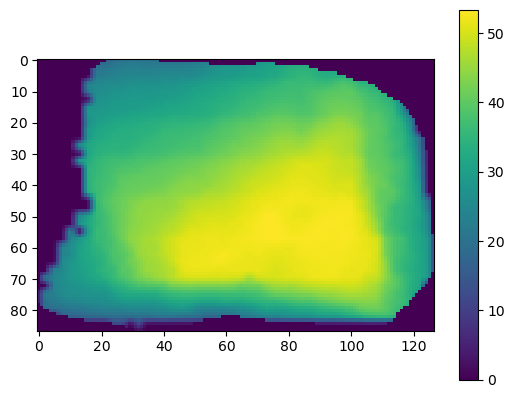

In [7]:
plt.imshow(thickness)
plt.colorbar()

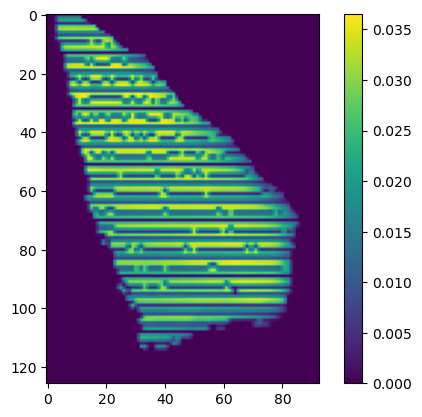

In [10]:
plt.imshow(thickness)
plt.colorbar()

In [9]:
thickness[20, 20]

0.018831462

In [6]:
img = cv.imread('e:\\multi_source_info\\lidar\\pcd_data\\stitched_ore.jpg', )
img = cv.resize(img, (1024, 1800), interpolation=cv.INTER_AREA)

# 再转颜色
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

(-0.5, 1023.5, 1649.5, -0.5)

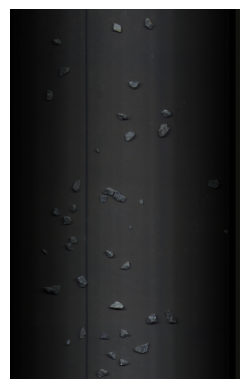

In [9]:
plt.imshow(img[150:, :])
plt.axis('off')

In [3]:
combined = simple.simple_stitch_ore_pcd("pcd_data/vzcoal/", "simple_stitched.ply")

找到 20 个PCD文件


In [4]:
o3d.visualization.draw_geometries(
    [combined],
    window_name="矿石点云拼接结果",
    width=1200,
    height=800,
    point_show_normal=False
)

In [4]:
pcd = o3d.io.read_point_cloud("../pcd_data/vzcoal-detect-data-17.pcd")
print(pcd)

# 获取深度（Z值）
points = np.asarray(pcd.points)
print(points.shape)
depths = points[:, 2]  # 所有点的深度值

# 统计深度信息
print(f"最小深度: {depths.min():.3f}m")
print(f"最大深度: {depths.max():.3f}m")
print(f"平均深度: {depths.mean():.3f}m")

# 可视化
o3d.visualization.draw_geometries([pcd])

PointCloud with 36652 points.
(36652, 3)
最小深度: 876.049m
最大深度: 933.145m
平均深度: 925.027m
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: 不支持请求的转换操作。 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: 句柄无效。 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: 不支持请求的转换操作。 


In [2]:
# pcd = o3d.io.read_point_cloud("../pcd_data/combined_cloud_0121.ply")
# pcd = o3d.io.read_point_cloud("../pcd_data/SaveData_0205_cropped.ply")
pcd = o3d.io.read_point_cloud("../pcd_data/SaveData_contours_test_0227.ply")
print(f"点数: {len(pcd.points)}")
print(f"颜色: {'有' if pcd.has_colors() else '无'}")
print(f"法向量: {'有' if pcd.has_normals() else '无'}")

点数: 3269784
颜色: 有
法向量: 无


True

In [11]:
# 获取边界框
min_bound = pcd.get_min_bound()  # [min_x, min_y, min_z]
max_bound = pcd.get_max_bound()  # [max_x, max_y, max_z]

# 提取z方向的最小值和最大值
z_min = min_bound[2]
z_max = max_bound[2]

print(f"z方向最小值: {z_min}")
print(f"z方向最大值: {z_max}")

# 提取z方向的最小值和最大值
y_min = min_bound[1]
y_max = max_bound[1]

print(f"y方向最小值: {y_min}")
print(f"y方向最大值: {y_max}")

z方向最小值: -50.61727344174312
z方向最大值: 8.333776362944377
y方向最小值: -472.38583317082765
y方向最大值: 476.0883794756567


In [3]:
pcd.colors = o3d.utility.Vector3dVector()
o3d.visualization.draw_geometries([pcd])